In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc, average_precision_score
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

# تنظیمات برای نمودارها
sns.set(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Tahoma']
plt.rcParams['axes.unicode_minus'] = False # برای نمایش صحیح علامت منفی


In [2]:
df = pd.read_csv("../data/raw/creditcard.csv")
X = df.drop("Class", axis=1)
y = df["Class"]

print(f"Dataset loaded. Features shape: {X.shape}")
print("\nTarget distribution:")
print(y.value_counts())


Dataset loaded. Features shape: (284807, 30)

Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y 
)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Training set size: 227845
Test set size: 56962


In [4]:
#  آموزش مدل LightGBM
clf = lgb.LGBMClassifier(random_state=42, verbosity=-1)
print("Training model...")
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_probs = clf.predict_proba(X_test)[:, 1]
print("Training finished.")


Training model...
Training finished.


In [5]:
#  گزارش نتایج و معیارهای ارزیابی
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_probs)
pr_auc = average_precision_score(y_test, y_probs)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Average Precision (PR-AUC): {pr_auc:.4f}")



--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.39      0.43      0.41        98

    accuracy                           1.00     56962
   macro avg       0.70      0.71      0.70     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.7095
Average Precision (PR-AUC): 0.1870


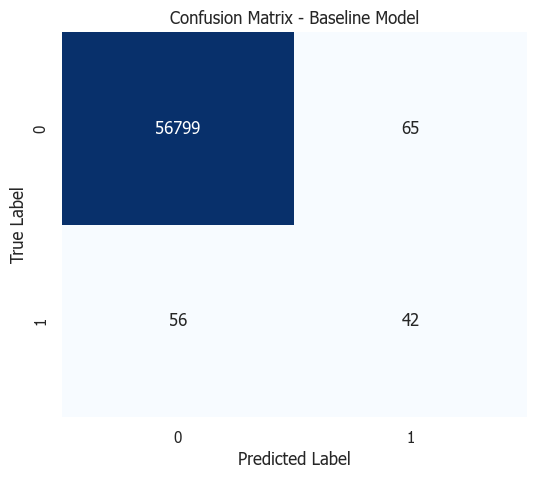

In [6]:
#  (Confusion Matrix) رسم ماتریس سردرگمی
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Baseline Model')
plt.show()


In [7]:
# آموزش مدل بهبود یافته با وزن‌دهی به کلاس‌ها
clf_weighted = lgb.LGBMClassifier(random_state=42, class_weight='balanced', verbosity=-1)
print("Training weighted model...")
clf_weighted.fit(X_train, y_train)

y_pred_weighted = clf_weighted.predict(X_test)
y_probs_weighted = clf_weighted.predict_proba(X_test)[:, 1]
print("Training finished.")


Training weighted model...
Training finished.


In [8]:
# گزارش نتایج مدل بهبود یافته
print("\n--- Classification Report (Weighted Model) ---")
print(classification_report(y_test, y_pred_weighted))

roc_auc_w = roc_auc_score(y_test, y_probs_weighted)
pr_auc_w = average_precision_score(y_test, y_probs_weighted)

print(f"ROC-AUC: {roc_auc_w:.4f}")
print(f"Average Precision (PR-AUC): {pr_auc_w:.4f}")



--- Classification Report (Weighted Model) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.87      0.84        98

    accuracy                           1.00     56962
   macro avg       0.91      0.93      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9770
Average Precision (PR-AUC): 0.8864


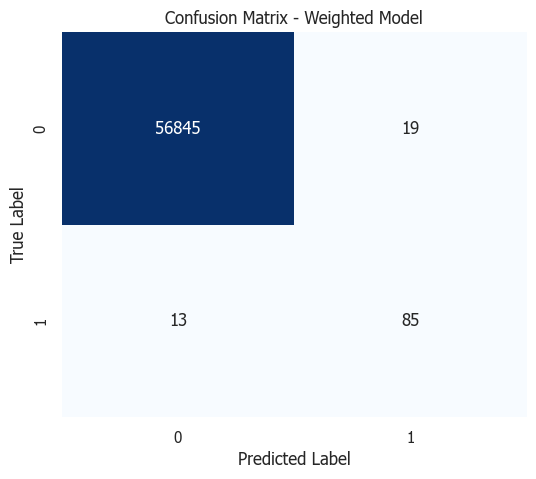

In [9]:
# رسم ماتریس سردرگمی مدل وزن‌دار
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_weighted)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Weighted Model')
plt.show()


In [10]:
# مقایسه مدل پایه و مدل وزن‌دار
results = pd.DataFrame({
    'Model': ['Baseline', 'Weighted'],
    'ROC-AUC': [roc_auc, roc_auc_w],
    'PR-AUC': [pr_auc, pr_auc_w]
})

print(results)


      Model   ROC-AUC    PR-AUC
0  Baseline  0.709534  0.186993
1  Weighted  0.976998  0.886438


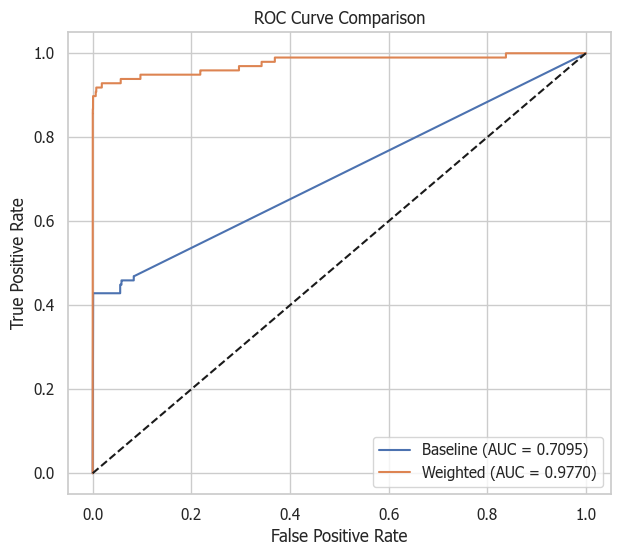

In [11]:
# رسم ROC Curve
from sklearn.metrics import roc_curve

fpr1, tpr1, _ = roc_curve(y_test, y_probs)
fpr2, tpr2, _ = roc_curve(y_test, y_probs_weighted)

plt.figure(figsize=(7, 6))
plt.plot(fpr1, tpr1, label=f'Baseline (AUC = {roc_auc:.4f})')
plt.plot(fpr2, tpr2, label=f'Weighted (AUC = {roc_auc_w:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()


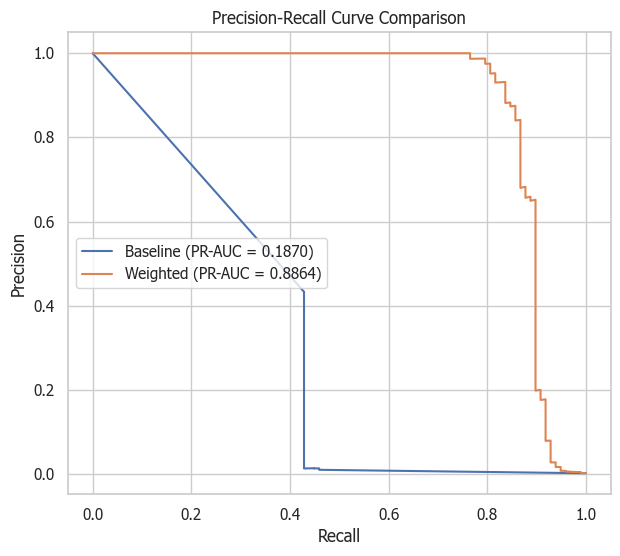

In [12]:
# رسم Precision-Recall Curve
from sklearn.metrics import precision_recall_curve

precision1, recall1, _ = precision_recall_curve(y_test, y_probs)
precision2, recall2, _ = precision_recall_curve(y_test, y_probs_weighted)

plt.figure(figsize=(7, 6))
plt.plot(recall1, precision1, label=f'Baseline (PR-AUC = {pr_auc:.4f})')
plt.plot(recall2, precision2, label=f'Weighted (PR-AUC = {pr_auc_w:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.show()
